# 02 · Exploratory Data Analysis

**Notebook:** 02 of 04  

**Goal:** Discover patterns through bivariate and multivariate analysis.

### What this notebook covers
- Bivariate analysis: gender, dependents, property area, loan term, credit history, total income
- Multivariate analysis: marital status × dependents interaction
- Final business recommendations
- Outlier check across all numeric features and 

In [38]:
import plotly.express as px
import pandas as pd
import numpy as np

# for plotly visualizations in SVG format for github
import plotly.io as pio
pio.renderers.default = 'svg'

In [39]:
# ── Load cleaned data after cleaning ───────────────────────────────────────
df = pd.read_csv("data/01_cleaned.csv")
print(f"Loaded → shape: {df.shape}")
df.head(3)

Loaded → shape: (614, 14)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,log_ApplicantIncome,log_LoanAmount
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,8.674026,NaN
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,8.430109,4.852030
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,8.006368,4.189655


# **Bivariate Analysis**

### We performed bivariate analysis to explore the relationships between the features and the target variable. This step helps us identify the most important features and discover meaningful patterns in the data.

In [40]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'log_ApplicantIncome', 'log_LoanAmount'],
      dtype='object')

## 1- Does gender influence loan approval rates?

In [41]:
df.Gender.value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

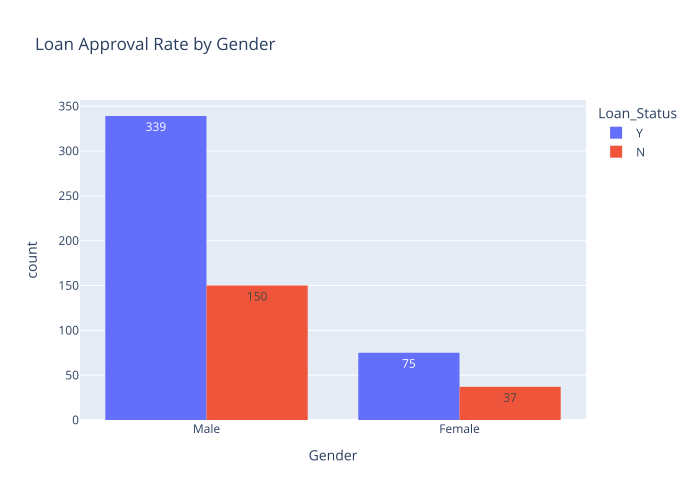

In [42]:
fig = px.histogram(
    df,
    x="Gender",
    color="Loan_Status",
    barmode="group",
    title="Loan Approval Rate by Gender",
    text_auto=True
)

fig.show()

### Summary Insight:

#### - **Male applicants have a much higher number of approvals (339) compared to rejections (150).**

#### - **Female applicants also have more approvals (75) than rejections (37), but their total applications are far fewer than males**


## 2-Is there a relationship between number of dependents and loan approval?

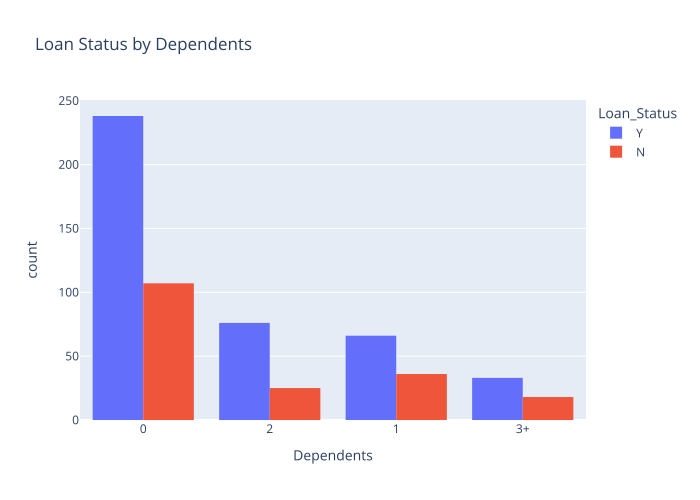

In [43]:
fig = px.histogram(df, x='Dependents', color='Loan_Status',
                   barmode='group',
                   title='Loan Status by Dependents ')
fig.show()


### Summary Insight:
#### **Applicants with 0 dependents have the highest approval counts, likely due to lower financial burdens**

## 3-Do property area affect loan approval?

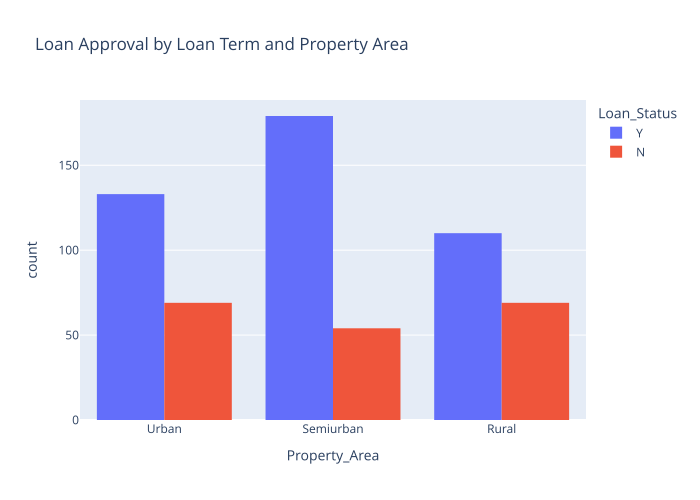

In [44]:
fig = px.histogram(df, x= "Property_Area", color='Loan_Status',
                    barmode='group',
                   title='Loan Approval by Loan Term and Property Area')
fig.show()


### Summary Insight:
#### **Semiurban areas have the highest approval count, followed by rural and urban**

## 4-Are shorter or longer loans more likely to be approved?

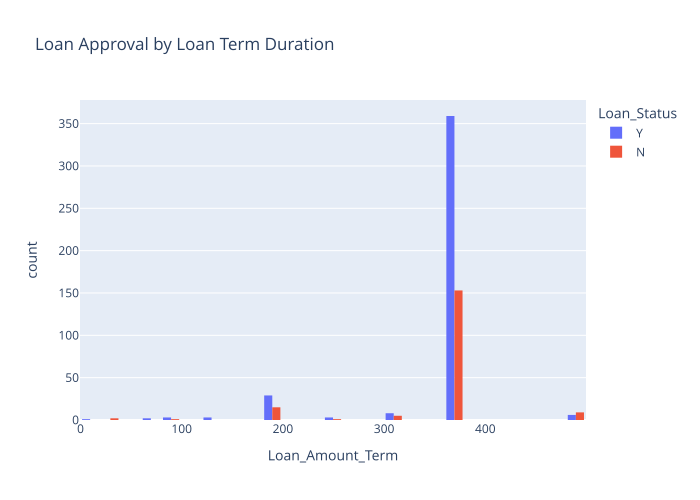

In [45]:
fig = px.histogram(df, x='Loan_Amount_Term', color='Loan_Status', barmode='group',
                   title='Loan Approval by Loan Term Duration')
fig.show()

### Summary Insight:
#### **Longer loans are more likely to be approved**

## 5- How does credit history impact loan approval?

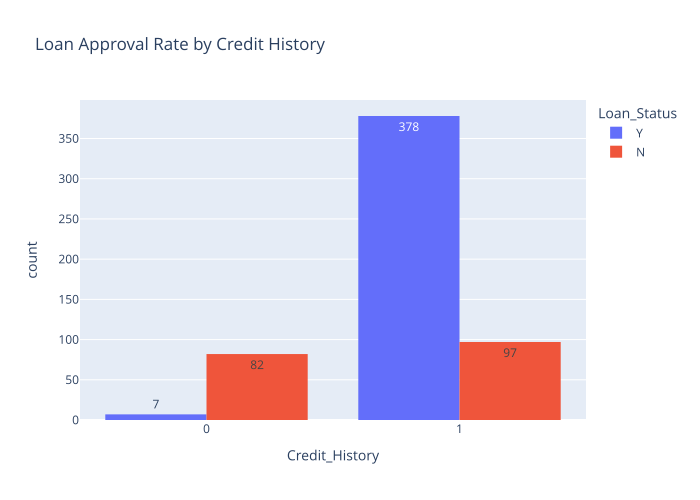

In [46]:
fig = px.histogram(
    df,
    x="Credit_History",
    color="Loan_Status",
    barmode="group",
    title="Loan Approval Rate by Credit History",
    text_auto=True
)

fig.show()

### Summary Insight:

#### - **Applicants with a good credit history (1) have a very high approval count (378) compared to rejections (97), showing strong positive influence on approval.**

#### - **Applicants with no/poor credit history (0) face a significant disadvantage — only 7 approvals vs 82 rejections.**

#### - **Credit history is a critical factor in loan approval, with a clear pattern that having it significantly boosts chances.**

## 6- Does total household income affect loan approval?

In [47]:
# create Total_Income to make analysis
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]


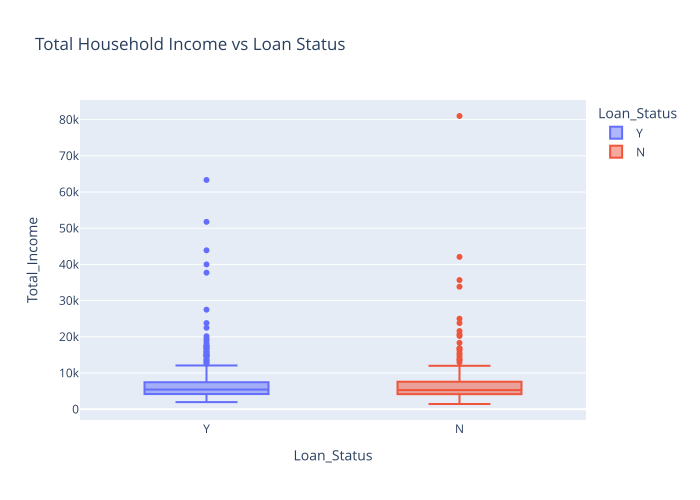

In [48]:
fig = px.box(
    df,
    x="Loan_Status",
    y="Total_Income",
    color="Loan_Status",
    title="Total Household Income vs Loan Status"
)

fig.show()

### Summary Insight:

#### - **The median total household income is quite similar for both approved and rejected loans, suggesting income alone isn’t a strong approval driver.**

#### - **There are more high-income outliers among rejected applications, meaning some high earners still face denials — likely due to other factors like credit history or loan-to-income ratio.**



In [49]:
df.Married.value_counts()

Married
Yes    398
No     213
Name: count, dtype: int64

In [50]:
df.Dependents.value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

# Multivariate analysis

## 7-What is Impact of Marital Status and Dependents on Loan Approval

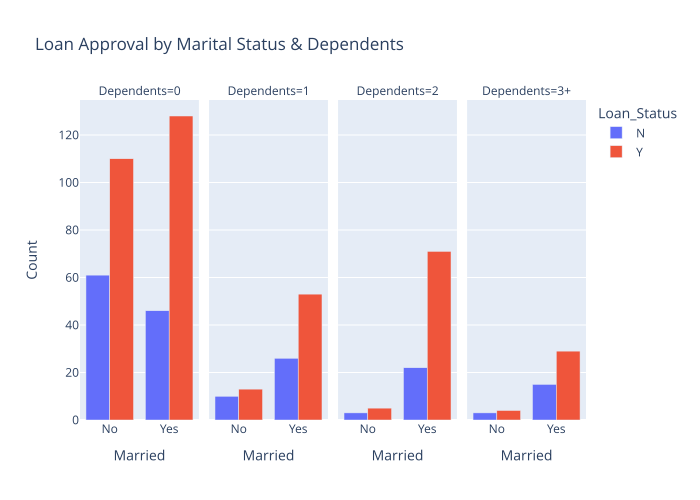

,Married,Dependents,Loan_Status,Count
0,No,0,N,61
1,No,0,Y,110
2,No,1,N,10
3,No,1,Y,13
4,No,2,N,3
5,No,2,Y,5
6,No,3+,N,3
7,No,3+,Y,4
8,Yes,0,N,46
9,Yes,0,Y,128


In [51]:
married_dependents = df.groupby(['Married','Dependents','Loan_Status']).size().reset_index(name='Count')
fig = px.bar(married_dependents, x='Married', y='Count', color='Loan_Status',
             facet_col='Dependents', barmode='group',
             title='Loan Approval by Marital Status & Dependents')
fig.show()

married_dependents

### insights :
- **Single people with no kids → Highest chance to get loan (best customers)**
- **Married + 1 child → Also very good chance (bank loves them)**
- **Married + 2 children → Okay, but lower chance than 0 or 1 child**
- **Married + 3 or more children → Very high chance of rejection (bank says no most of the time)**
- **Single with 3+ kids → Very rare, but when they apply, bank usually says yes**

------------------------------------------------------------------------------------------------------------------------------------

# Final Recommendations

#### 1- Prioritize Credit History

- **Credit history is the strongest predictor of loan approval. Applicants with good credit should receive priority, while those with poor or missing credit must undergo additional checks.**

#### 2- Use Dependents and Marital Status as Stability Indicators

- **Applicants with 0–1 dependents show the highest approval likelihood.**
**Those with 3+ dependents represent high financial pressure and should be assessed more cautiously.****

#### 3- Do Not Rely on Income Alone

- **Median income is similar across approved and rejected groups.**
**Income should always be evaluated together with loan amount, dependents, and credit history.**

#### 4- Encourage Longer Loan Terms

- **Longer loan durations correlate with higher approval rates because they reduce monthly installment pressure.**
**Applicants on the edge can benefit from extending their loan term.**

#### 5- Incorporate Property Area into Risk Assessment

- **Semiurban applicants have the highest approval rates.**
**Semiurban areas can receive a slight positive score adjustment, while urban areas may need stricter checks.**

#### 6- Treat Gender as a Non-Critical Factor

- **Approval differences come from application volume—not approval bias.**
**Gender should not play a major role in model predictions.**


#### 7- Investigate High-Income Rejections

- **Some high-income applicants are still rejected, which indicates other strong risk signals (e.g., poor credit history or high loan-to-income ratio).**
**These cases should be reviewed with additional scrutiny.**

# Check Outliers

In [52]:
from datasist.structdata import detect_outliers


DF = df.select_dtypes(include="number")

for col in DF.columns:
    outliers = detect_outliers(df, 0, [col])
    print(f"{col}: {len(outliers)} outliers")


ApplicantIncome: 50 outliers
CoapplicantIncome: 18 outliers
LoanAmount: 0 outliers
Loan_Amount_Term: 0 outliers
Credit_History: 0 outliers
log_ApplicantIncome: 27 outliers
log_LoanAmount: 0 outliers
Total_Income: 50 outliers


In [53]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [54]:
# ── Save EDA data for notebook 03 ────────────────────────────────────────────
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/02_eda_clean.csv", index=False)
print(f"Saved → data/02_eda_clean.csv  |  shape: {df.shape}")

Saved → data/02_eda_clean.csv  |  shape: (614, 15)
